In [1]:
from helper_functions import *
import sys
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import sklearn
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras import models
import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error

2026-06-06 14:47:26.542053: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
all_wind_data_1 = pd.read_csv('/Users/rasmus/Desktop/Fysik/AppliedML2026/AppMLFinalProject/All_wind_data_2.csv')
flights = pd.read_csv('/Users/rasmus/Desktop/Fysik/AppliedML2026/AppMLFinalProject/y_data_rms.csv')


Replace vector wind speed and direction with u and v components

In [8]:
df = all_wind_data_1.merge(flights[['source_file', 'bottom_rms']], on='source_file').reset_index(drop=True)
df = df.dropna(subset=['bottom_rms'])

X = df.drop(columns=['bottom_rms'])
y = df['bottom_rms']

def add_uv(df, prefix):
    speed = df[f"{prefix}.VectorMeanWindSpeed"]
    direction = df[f"{prefix}.VectorMeanWindDirection"]

    df[f"{prefix}_u"] = speed * np.cos(direction)
    df[f"{prefix}_v"] = speed * np.sin(direction)

    return df

all_wind_data = add_uv(X, 'W04')
all_wind_data = add_uv(X, 'W22')
all_wind_data.drop(columns=['W04.VectorMeanWindSpeed', 'W04.VectorMeanWindDirection', 'W22.VectorMeanWindSpeed', 'W22.VectorMeanWindDirection'], inplace=True)

print(all_wind_data.shape)
print(flights.shape)

(335714, 31)
(2827, 11)


Create tensors. Since datapoints in every wind file is different, truncate to the shortest one, and line up with the flight data.

In [ ]:
feature_cols = all_wind_data.columns.tolist()[8:]

feature_cols.remove('W04.OkPct')
feature_cols.remove('W22.OkPct')
feature_cols.remove('source_file')

flights_lookup = (
    flights
    .set_index("source_file")["bottom_rms"])
X_list = []
y_list = []

for source_file, group in all_wind_data.groupby("source_file"):

    if source_file not in flights_lookup.index:
        continue

    seq = group[feature_cols].values

    X_list.append(seq)
    y_list.append(flights_lookup.loc[source_file])

lengths = [len(x) for x in X_list]

min_len = 119

X = np.stack([
    seq[:min_len]
    for seq in X_list
])

print(X.shape)
y = np.array(y_list)
print(y.shape)

(2793, 119, 20)
(2793,)


Shapes now match. Now train-test-split and scaling of the features

In [16]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=False)

n_samples, n_steps, n_features = X_train.shape
n_val = X_val.shape[0]

scaler = StandardScaler()
y_scaler = StandardScaler()


X_train_reshaped = X_train.reshape(-1, n_features)
X_val_reshaped = X_val.reshape(-1, n_features)

X_train_scaled = scaler.fit_transform(X_train_reshaped)
X_val_scaled = scaler.transform(X_val_reshaped)

X_train_scaled = X_train_scaled.reshape(
    n_samples,
    n_steps,
    n_features
)
X_val_scaled = X_val_scaled.reshape(
    n_val,
    n_steps,
    n_features)

y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1)).flatten()
y_val_scaled = y_scaler.transform(y_val.reshape(-1, 1)).flatten()


In [21]:
model = models.Sequential([
    
    layers.Conv1D(
        filters=32,
        kernel_size=5,
        activation="relu",
        padding="same"
    ),

    layers.BatchNormalization(),

    layers.Conv1D(
        filters=64,
        kernel_size=5,
        activation="relu",
        padding="same"
    ),

    layers.BatchNormalization(),

    layers.GlobalMaxPooling1D(),

    layers.Dense(
        64,
        activation="relu"
    ),

    layers.Dropout(0.3),

    layers.Dense(1)
])
#model.summary()
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=3e-4
    ),
    #loss="mse",
    loss = tf.keras.losses.Huber(delta=1.0),
    metrics=["mae"])

callbacks = [

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=4
    )
]

history = model.fit(
    X_train_scaled,
    y_train_scaled,
    validation_data=(X_val_scaled, y_val_scaled),
    epochs=40,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 9s 47ms/step - loss: 1.2467 - mae: 1.6793 - val_loss: 0.4925 - val_mae: 0.9019 - learning_rate: 3.0000e-04
Epoch 2/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 0.7202 - mae: 1.1220 - val_loss: 0.4653 - val_mae: 0.8701 - learning_rate: 3.0000e-04
Epoch 3/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.5286 - mae: 0.9105 - val_loss: 0.4325 - val_mae: 0.8311 - learning_rate: 3.0000e-04
Epoch 4/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.4435 - mae: 0.8156 - val_loss: 0.4073 - val_mae: 0.7937 - learning_rate: 3.0000e-04
Epoch 5/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 0.3899 - mae: 0.7486 - val_loss: 0.4052 - val_mae: 0.7770 - learning_rate: 3.0000e-04
Epoch 6/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 0.3667 - mae: 0.7212 - val_loss: 0.3929 - val_mae: 0.7658 - learning_rate: 3.0000e-04
Epoch 7/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - loss: 0.3490 - mae: 0.7019 - val_loss: 0.3876 - val_mae: 0.7519 - learning_ra

17/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


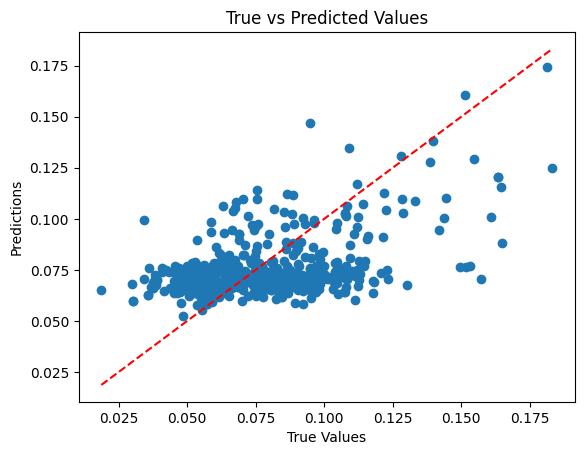

In [23]:
y_pred = model.predict(X_val_scaled).flatten()
y_pred_rescaled = y_scaler.inverse_transform(y_pred.reshape(-1, 1)).flatten()


plt.plot(y_val, y_pred_rescaled, 'o')
#Plot diagonal line
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.title('True vs Predicted Values')
plt.show()

In [18]:

model = models.Sequential([

    layers.Conv1D(32, 5, padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    layers.Conv1D(32, 5, padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    layers.MaxPooling1D(2),

    layers.Conv1D(64, 3, padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    layers.Conv1D(64, 3, padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    layers.GlobalMaxPooling1D(),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.4),

    layers.Dense(1)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=3e-4
    ),
    #loss="mse",
    loss = tf.keras.losses.Huber(delta=1.0),
    metrics=["mae"])

callbacks = [

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=4
    )
]

history = model.fit(
    X_train_scaled,
    y_train_scaled,
    validation_data=(X_val_scaled, y_val_scaled),
    epochs=40,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/40


KeyboardInterrupt: 

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
MAPE: 0.2884


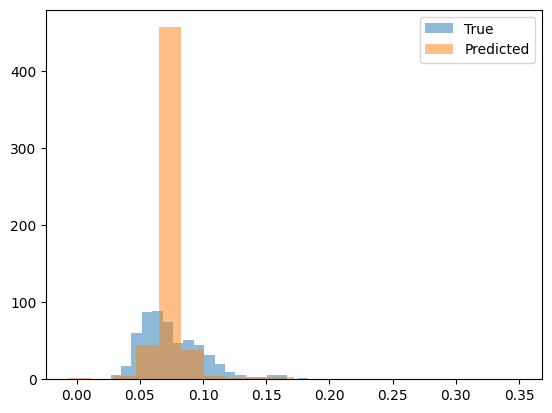

In [ ]:
y_pred = model.predict(X_val_scaled).flatten()
y_pred = y_scaler.inverse_transform(y_pred.reshape(-1, 1)).flatten()
mape = mean_absolute_percentage_error(y_val, y_pred)
print(f"MAPE: {mape:.4f}")

plt.hist(y_val, bins=20, alpha=0.5, label="True")
plt.hist(y_pred, bins=20, alpha=0.5, label="Predicted")
plt.legend()
plt.show()
#model.save('best.keras')

In [15]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import r2_score, mean_absolute_error

dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train.reshape(len(X_train), -1), y_train)

y_pred_dummy = dummy.predict(X_val.reshape(len(X_val), -1))

print("Dummy R2:", r2_score(y_val, y_pred_dummy))
print("Dummy MAE:", mean_absolute_error(y_val, y_pred_dummy))
print("Model R2:", r2_score(y_val, y_pred))
print("Model MAE:", mean_absolute_error(y_val, y_pred))

Dummy R2: -0.0025031287109029687
Dummy MAE: 0.0199581104096833
Model R2: -0.3420719846109568
Model MAE: 0.020641778506402638


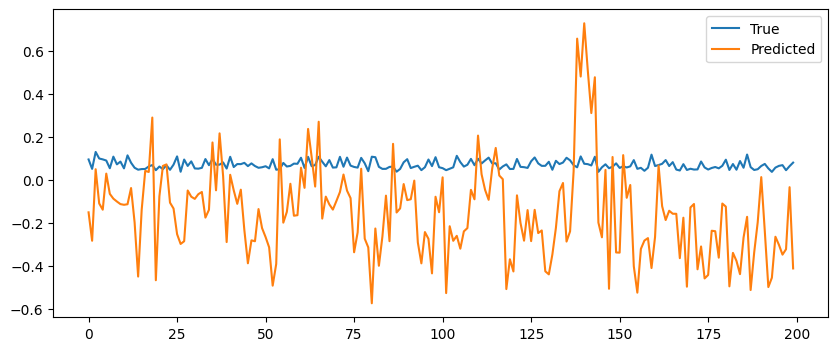

In [44]:
plt.figure(figsize=(10,4))
plt.plot(y_val[:200], label="True")
plt.plot(y_pred[:200], label="Predicted")
plt.legend()
plt.show()

CNN with uncertainty:

In [38]:
y_train = y_train.reshape(-1)
y_val = y_val.reshape(-1)
model = models.Sequential([

    layers.Conv1D(32, 5, padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    layers.Conv1D(32, 5, padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    layers.MaxPooling1D(2),

    layers.Conv1D(64, 3, padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    layers.Conv1D(64, 3, padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    layers.GlobalMaxPooling1D(),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.4),

    layers.Dense(2)
])

def nll_gaussian(y_true, y_pred):
    y_true = tf.reshape(y_true, (-1,))
    mu = y_pred[:, 0]
    log_sigma = y_pred[:, 1]

    sigma = tf.exp(log_sigma) + 1e-3
    sigma = tf.clip_by_value(sigma, 1e-3, 5.0)

    return tf.reduce_mean(
        0.5 * tf.math.log(sigma**2) +
        0.5 * ((y_true - mu)**2 / (sigma**2)) )

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=3e-4
    ),
    #loss="mse",
    loss = nll_gaussian)

callbacks = [

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=4
    )]

history = model.fit(
    X_train_scaled,
    y_train_scaled,
    validation_data=(X_val_scaled, y_val_scaled),
    epochs=40,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 13s 46ms/step - loss: 31.3318 - val_loss: 0.7822 - learning_rate: 3.0000e-04
Epoch 2/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 2.0206 - val_loss: 1.0644 - learning_rate: 3.0000e-04
Epoch 3/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 1.9158 - val_loss: 1.4104 - learning_rate: 3.0000e-04
Epoch 4/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 1.8122 - val_loss: 1.5593 - learning_rate: 3.0000e-04
Epoch 5/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 1.6761 - val_loss: 1.6005 - learning_rate: 3.0000e-04
Epoch 6/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 1.6430 - val_loss: 1.6176 - learning_rate: 1.5000e-04
Epoch 7/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 1.6736 - val_loss: 1.6291 - learning_rate: 1.5000e-04
Epoch 8/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 1.6565 - val_loss: 1.6296 - learning_rate: 1.5000e-04
Epoch 9/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 1.7276 - val_loss: 1.6329 - learnin

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step


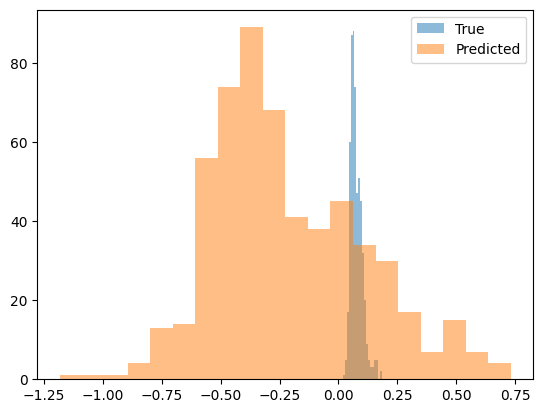

In [39]:
pred = model.predict(X_val_scaled)

mu = pred[:, 0]
log_sigma = pred[:, 1]

sigma = np.exp(log_sigma)

plt.hist(y_val, bins=20, alpha=0.5, label="True")
plt.hist(mu, bins=20, alpha=0.5, label="Predicted")
plt.legend()
plt.show()

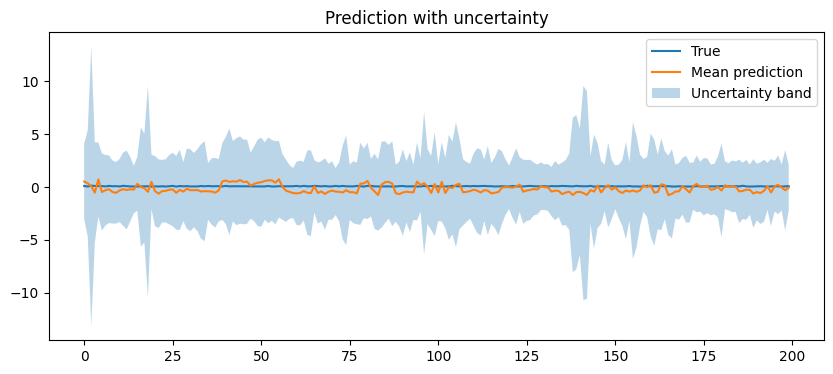

In [41]:
plt.figure(figsize=(10,4))

plt.plot(y_val[:200], label="True")
plt.plot(mu[:200], label="Mean prediction")

plt.fill_between(
    range(200),
    mu[:200] - 2*sigma[:200],
    mu[:200] + 2*sigma[:200],
    alpha=0.3,
    label="Uncertainty band"
)

plt.legend()
plt.title("Prediction with uncertainty")
plt.show()

In [ ]:
isa_data = pd.read_csv('/Users/rasmus/Desktop/Fysik/AppliedML2026/AppMLFinalProject/Isa/DATA3140.csv')
isa_data['source_file'] = isa_data['source_file'].str.split('/').str[-1]
all_wind_data['source_file'] = all_wind_data['source_file'].str.split('/').str[-1]

isa_files = isa_data['source_file'].unique()
common = set(isa_files) & set(all_wind_data['source_file'].unique())

X_isa = all_wind_data[all_wind_data['source_file'].isin(common)]
isa_data = isa_data[isa_data['source_file'].isin(common)]

In [ ]:
feature_cols = all_wind_data.columns.tolist()[8:]
feature_cols.remove('W04.OkPct')
feature_cols.remove('W22.OkPct')
feature_cols.remove('source_file')

flights_lookup = (isa_data.set_index("source_file")["turbulence_max"])

X_list = []
y_list = []

for source_file, group in all_wind_data.groupby("source_file"):

    if source_file not in flights_lookup.index:
        continue

    seq = group[feature_cols].values

    X_list.append(seq)
    y_list.append(flights_lookup.loc[source_file])

lengths = [len(x) for x in X_list]

min_len = np.min(lengths)

X = np.stack([
    seq[:min_len]
    for seq in X_list
])

print(X.shape)
y = np.array(y_list)
print(y.shape)

(2772, 119, 20)
(2772,)


In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=False)

n_samples, n_steps, n_features = X_train.shape
n_val = X_val.shape[0]

scaler = StandardScaler()


X_train_reshaped = X_train.reshape(-1, n_features)
X_val_reshaped = X_val.reshape(-1, n_features)

X_train_scaled = scaler.fit_transform(X_train_reshaped)
X_val_scaled = scaler.transform(X_val_reshaped)

X_train_scaled = X_train_scaled.reshape(
    n_samples,
    n_steps,
    n_features
)
X_val_scaled = X_val_scaled.reshape(
    n_val,
    n_steps,
    n_features)

y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)

In [ ]:
model = models.Sequential([

    layers.Conv1D(32, 5, padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    layers.Conv1D(32, 5, padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    layers.MaxPooling1D(2),

    layers.Conv1D(64, 3, padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    layers.Conv1D(64, 3, padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    layers.GlobalMaxPooling1D(),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.35),

    layers.Dense(1)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=3e-4
    ),
    #loss="mse",
    loss = tf.keras.losses.Huber(delta=1.0),
    metrics=["mae"])

callbacks = [

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=4
    )
]

history = model.fit(
    X_train_scaled,
    y_train_log,
    validation_data=(X_val_scaled, y_val_log),
    epochs=40,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - loss: 0.4943 - mae: 0.8610 - val_loss: 0.2613 - val_mae: 0.7084 - learning_rate: 3.0000e-04
Epoch 2/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.1355 - mae: 0.4059 - val_loss: 0.1145 - val_mae: 0.4570 - learning_rate: 3.0000e-04
Epoch 3/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0520 - mae: 0.2513 - val_loss: 0.0612 - val_mae: 0.3038 - learning_rate: 3.0000e-04
Epoch 4/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0346 - mae: 0.2039 - val_loss: 0.0382 - val_mae: 0.2094 - learning_rate: 3.0000e-04
Epoch 5/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0246 - mae: 0.1760 - val_loss: 0.0150 - val_mae: 0.1410 - learning_rate: 3.0000e-04
Epoch 6/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0213 - mae: 0.1633 - val_loss: 0.0095 - val_mae: 0.1111 - learning_rate: 3.0000e-04
Epoch 7/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0194 - mae: 0.1568 - val_loss: 0.0092 - val_mae: 0.1101 - learning_r

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
MAPE: 0.0859
Model R2: -0.8656058982138568
Baseline R2: -0.002616804757325397


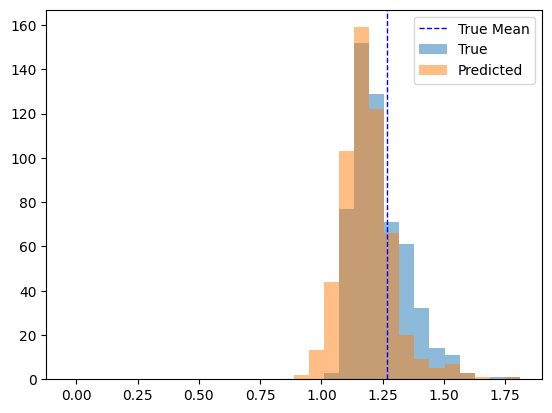

In [ ]:
y_pred = model.predict(X_val_scaled).flatten()
y_pred = np.expm1(y_pred)
mape = mean_absolute_percentage_error(y_val, y_pred)
print(f"MAPE: {mape:.4f}")
baseline = np.mean(y_train)

print("Model R2:", sklearn.metrics.r2_score(y_val, y_pred))
print("Baseline R2:", sklearn.metrics.r2_score(y_val, np.full_like(y_val, baseline)))

val_hist = np.histogram(y_val, bins=30, range=(0, np.max(y_val)))
pred_hist = np.histogram(y_pred, bins=30, range=(0, np.max(y_val)))
plt.bar(val_hist[1][:-1], val_hist[0], width=val_hist[1][1]-val_hist[1][0], alpha=0.5, label="True")
plt.bar(pred_hist[1][:-1], pred_hist[0], width=pred_hist[1][1]-pred_hist[1][0], alpha=0.5, label="Predicted")
plt.axvline(np.mean(y_val), color='blue', linestyle='dashed', linewidth=1, label="True Mean")
plt.legend()
plt.show()


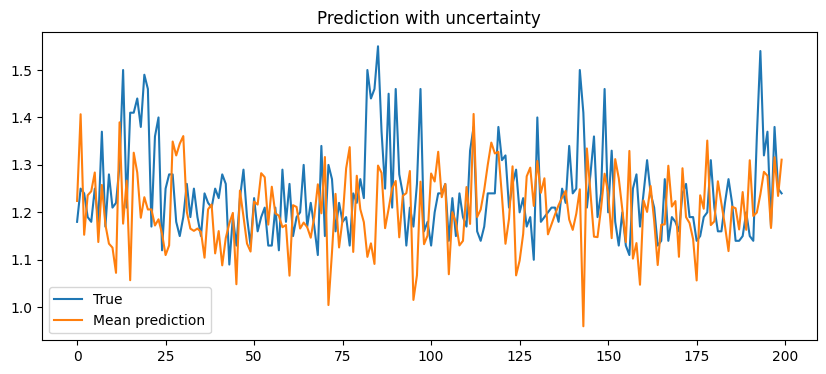

In [ ]:
plt.figure(figsize=(10,4))

plt.plot(y_val[:200], label="True")
plt.plot(y_pred[:200], label="Mean prediction")

#plt.fill_between(
#    range(200),
#    mu[:200] - 2*sigma[:200],
#    mu[:200] + 2*sigma[:200],
#    alpha=0.3,
#    label="Uncertainty band"
#)

plt.legend()
plt.title("Prediction with uncertainty")
plt.show()

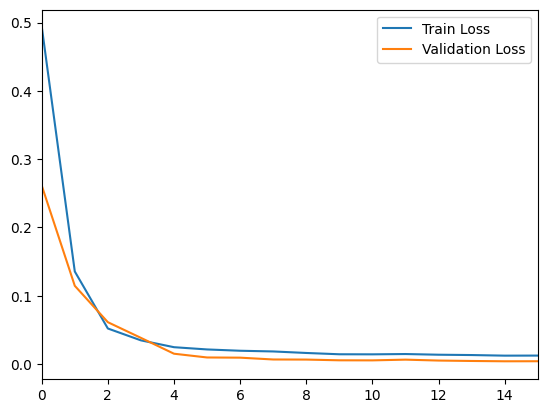

In [ ]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlim(0, 15)
plt.legend()
plt.show()

In [ ]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import r2_score, mean_absolute_error

dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train.reshape(len(X_train), -1), y_train)

y_pred_dummy = dummy.predict(X_val.reshape(len(X_val), -1))

print("Dummy R2:", r2_score(y_val, y_pred_dummy))
print("Dummy MAE:", mean_absolute_error(y_val, y_pred_dummy))
print("Model R2:", r2_score(y_val, y_pred))
print("Model MAE:", mean_absolute_error(y_val, y_pred))

Dummy R2: -0.002616804757325397
Dummy MAE: 0.08542442306989
Model R2: -0.8656058982138568
Model MAE: 0.11309683785996996


In [25]:
inputs = tf.keras.Input(shape=(119, 20))

# ----------------------------
# Block 1: local structure
# ----------------------------
x = layers.Conv1D(32, kernel_size=5, padding="same", activation=None)(inputs)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

# ----------------------------
# Block 2: medium-range structure
# ----------------------------
# Block
res = x

x = layers.Conv1D(64, 5, padding="same", activation="relu")(x)
x = layers.BatchNormalization()(x)

# match dimensions
res = layers.Conv1D(64, 1, padding="same")(res)

x = layers.Add()([x, res])
x = layers.Activation("relu")(x)

# ----------------------------
# Block 3: longer-range structure (temporal hierarchy)
# ----------------------------
x = layers.Conv1D(128, kernel_size=5, padding="same", activation="relu")(x)
x = layers.BatchNormalization()(x)

# ----------------------------
# IMPORTANT: only now do pooling
# ----------------------------
avg_pool = layers.GlobalAveragePooling1D()(x)
max_pool = layers.GlobalMaxPooling1D()(x)

x = layers.Concatenate()([avg_pool, max_pool])

# ----------------------------
# Regression head
# ----------------------------
x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(1)(x)

model = models.Model(inputs, outputs)

# ----------------------------
# Compile
# ----------------------------
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=3e-4,
        clipnorm=1.0
    ),
    loss=tf.keras.losses.Huber(delta=1.0),
    metrics=["mae"]
)

model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 119, 20)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_21 (Conv1D)  │ (None, 119, 32)   │      3,232 │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 119, 32)   │        128 │ conv1d_21[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_14       │ (None, 119, 32)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_22 (Conv1D)  │ (None, 119, 64)   │     10,304 │ activation_14[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 119, 64)   │        256 │ conv1d_22[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_23 (Conv1D)  │ (None, 119, 64)   │      2,112 │ activation_14[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 119, 64)   │          0 │ batch_normalizat… │
│                     │                   │            │ conv1d_23[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_15       │ (None, 119, 64)   │          0 │ add_1[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_24 (Conv1D)  │ (None, 119, 128)  │     41,088 │ activation_15[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 119, 128)  │        512 │ conv1d_24[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ batch_normalizat… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 256)       │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 64)        │     16,448 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 64)        │          0 │ dense_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 1)         │         65 │ dropout_6[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 74,145 (289.63 KB)

 Trainable params: 73,697 (287.88 KB)

 Non-trainable params: 448 (1.75 KB)

In [26]:
model.fit(
    X_train_scaled,
    y_train_scaled,
    validation_data=(X_val_scaled, y_val_scaled),
    epochs=40,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 16s 101ms/step - loss: 0.9295 - mae: 1.3403 - val_loss: 0.4529 - val_mae: 0.8364 - learning_rate: 3.0000e-04
Epoch 2/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step - loss: 0.4063 - mae: 0.7731 - val_loss: 0.3969 - val_mae: 0.7838 - learning_rate: 3.0000e-04
Epoch 3/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 7s 100ms/step - loss: 0.3636 - mae: 0.7194 - val_loss: 0.3804 - val_mae: 0.7551 - learning_rate: 3.0000e-04
Epoch 4/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - loss: 0.3461 - mae: 0.7001 - val_loss: 0.3744 - val_mae: 0.7476 - learning_rate: 3.0000e-04
Epoch 5/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step - loss: 0.3422 - mae: 0.6926 - val_loss: 0.3790 - val_mae: 0.7537 - learning_rate: 3.0000e-04
Epoch 6/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 6s 89ms/step - loss: 0.3318 - mae: 0.6821 - val_loss: 0.3955 - val_mae: 0.7684 - learning_rate: 3.0000e-04
Epoch 7/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 11s 156ms/step - loss: 0.3271 - mae: 0.6729 - val_loss: 0.3814 - val_mae: 0.7515 - learni

In [28]:
y_pred = model.predict(X_val_scaled).flatten()
y_pred_rescaled = y_scaler.inverse_transform(y_pred.reshape(-1, 1)).flatten()
mape = mean_absolute_percentage_error(y_val, y_pred_rescaled)
print(f"MAPE: {mape:.4f}")

baseline = np.mean(y_train)
print("Model R2:", r2_score(y_val, y_pred_rescaled))
print("Baseline R2:", r2_score(y_val, np.full_like(y_val, baseline)))



 4/18 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
MAPE: 0.2457
Model R2: 0.26207947568975776
Baseline R2: -0.0025031287109029687


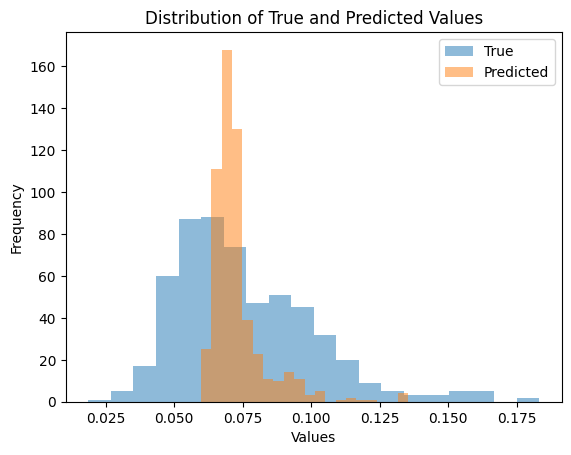

In [33]:
plt.hist(y_val, bins=20, alpha=0.5, label="True")
plt.hist(y_pred_rescaled, bins=20, alpha=0.5, label="Predicted")
plt.xlabel("Values")
plt.ylabel("Frequency")
plt.title("Distribution of True and Predicted Values")
plt.legend()
plt.show()

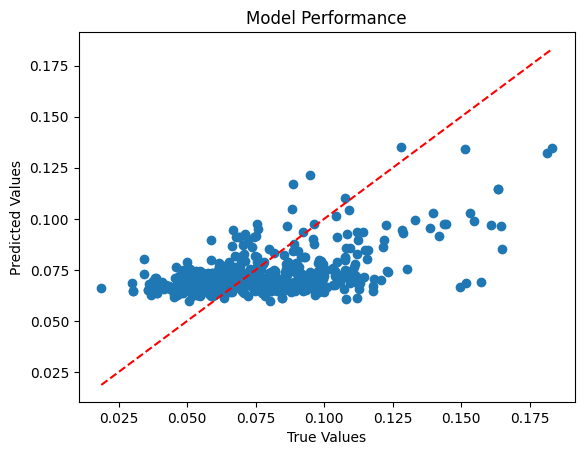

In [34]:
plt.plot(y_val, y_pred_rescaled, 'o')
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("Model Performance")
plt.show()

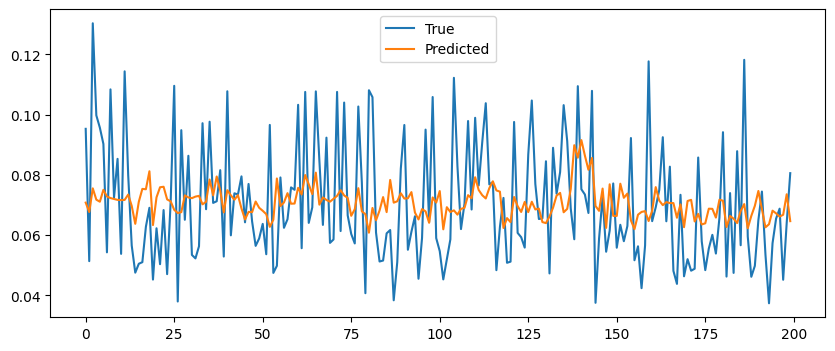

In [36]:
plt.figure(figsize=(10,4))
plt.plot(y_val[:200], label="True")
plt.plot(y_pred_rescaled[:200], label="Predicted")
plt.legend()